In [1]:
%load_ext watermark


In [2]:
import itertools as it
import os

import matplotlib as mpl
from matplotlib import pyplot as plt
import pandas as pd
from phyloframe import _auxlib as pfa
from phyloframe import legacy as pfl
from pyfonts import load_google_font
from teeplot import teeplot as tp

import pylib


/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/alifedata_phyloinformatics_convert/_impl/phytrack_Systematcs.py:7: UserWarning: ImportWarning: phylotrackpy.Systematics import failed; inserting a no-op mock for Systematics. This is likely because phylotrackpy is not installed.
  warnings.warn(


In [3]:
%watermark -diwmuv -iv


Last updated: 2026-03-18T03:16:05.871574+00:00

Python implementation: CPython
Python version       : 3.11.15
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1044-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

pandas    : 2.2.3
teeplot   : 1.4.2
pylib     : 0.0.0
phyloframe: 0.2.2
matplotlib: 3.10.0

Watermark: 2.4.3



In [4]:
teeplot_subdir = os.environ.get("NOTEBOOK_NAME", "2026-03-12-btr-foliage")
teeplot_subdir


'2026-03-12-btr-foliage'

In [5]:
pfa.seed_random(1)


In [6]:
font = load_google_font("Merriweather", weight=300)
mpl.font_manager.fontManager.addfont(font.get_file())
plt.rcParams["font.family"] = font.get_name()


## Prep Data


In [7]:
df_pure = pfl.alifestd_join_roots(
    pd.read_parquet("https://osf.io/vjhgs/download"),
)
df_pure


,id,dstream_data_id,ancestor_id,dstream_rank,hstrat_differentia_bitwidth,dstream_S,data_hex,bookend_left,bookend_right,bookend_value,...,CEREBRASLIB_HSTRAT_DSTREAM_ALGO_NAME,ASYNC_GA_GENOME_FLAVOR,is_extant,layer,layer_T,position,origin_time,hstrat_rank,is_root,is_oldest_root
0,0,NaN,0,NaN,NaN,NaN,None,NaN,NaN,NaN,...,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,True,True
1,1,NaN,0,NaN,NaN,NaN,None,NaN,NaN,NaN,...,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,False,False
2,2,NaN,0,190.0,1.0,96.0,None,NaN,NaN,NaN,...,NaN,NaN,None,NaN,NaN,NaN,94.0,94.0,False,False
3,3,NaN,2,382.0,1.0,96.0,None,NaN,NaN,NaN,...,NaN,NaN,None,NaN,NaN,NaN,286.0,286.0,False,False
4,4,NaN,3,574.0,1.0,96.0,None,NaN,NaN,NaN,...,NaN,NaN,None,NaN,NaN,NaN,478.0,478.0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99967,99967,1.009251e+09,98534,76091.0,1.0,96.0,bfb55c1e04a4f29ed05252d84bd80b3ad6a627d1,38682658.0,38682658.0,38682658.0,...,hybrid_0_steady_2_tilted_3_algo,genome_purifyingonly,False,1247.0,11297.0,151104.0,75995.0,75995.0,False,False
99968,99968,1.009495e+09,97878,76091.0,1.0,96.0,bfb5e23304a4f0f3d05252d81fd0f33f98b78d92,101105698.0,101105698.0,101105698.0,...,hybrid_0_steady_2_tilted_3_algo,genome_purifyingonly,False,1247.0,11297.0,394944.0,75995.0,75995.0,False,False
99969,99969,1.009207e+09,99869,76092.0,1.0,96.0,bfb5a2fa04a4f467d05252d84bd80b3a9c269853,27290658.0,27290658.0,27290658.0,...,hybrid_0_steady_2_tilted_3_algo,genome_purifyingonly,False,1247.0,11297.0,106604.0,75996.0,75996.0,False,False
99970,99970,1.009227e+09,99713,76093.0,1.0,96.0,bfb503e404a4f8c7d04253d84ad8ca3a7f468ed1,32388386.0,32388386.0,32388386.0,...,hybrid_0_steady_2_tilted_3_algo,genome_purifyingonly,False,1247.0,11297.0,126517.0,75997.0,75997.0,False,False


In [8]:
df_sweep = pfl.alifestd_join_roots(
    pd.read_parquet("https://osf.io/download/ajdsz"),
)
df_sweep


,id,dstream_data_id,ancestor_id,dstream_rank,hstrat_differentia_bitwidth,dstream_S,data_hex,bookend_left,bookend_right,bookend_value,...,CEREBRASLIB_HSTRAT_DSTREAM_ALGO_NAME,ASYNC_GA_GENOME_FLAVOR,is_extant,layer,layer_T,position,origin_time,hstrat_rank,is_root,is_oldest_root
0,0,NaN,0,NaN,NaN,NaN,None,NaN,NaN,NaN,...,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,True,True
1,1,NaN,0,NaN,NaN,NaN,None,NaN,NaN,NaN,...,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,False,False
2,2,NaN,0,766.0,1.0,96.0,None,NaN,NaN,NaN,...,NaN,NaN,None,NaN,NaN,NaN,670.0,670.0,False,False
3,3,NaN,2,1150.0,1.0,96.0,None,NaN,NaN,NaN,...,NaN,NaN,None,NaN,NaN,NaN,1054.0,1054.0,False,False
4,4,NaN,3,1534.0,1.0,96.0,None,NaN,NaN,NaN,...,NaN,NaN,None,NaN,NaN,NaN,1438.0,1438.0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99960,99960,1.009520e+09,99381,76063.0,1.0,96.0,7f7eff7304a4817b1fb1bf7f0be5f7eab61a22e0,107081138.0,107081138.0,107081138.0,...,hybrid_0_steady_2_tilted_3_algo,genome_purifyingplus,False,1247.0,13233.0,418285.0,75967.0,75967.0,False,False
99961,99961,1.009544e+09,98320,76065.0,1.0,96.0,7f7e777c04a489671fb5bf7e4bed29e88a089941,113309618.0,113309618.0,113309618.0,...,hybrid_0_steady_2_tilted_3_algo,genome_purifyingplus,False,1247.0,13233.0,442615.0,75969.0,75969.0,False,False
99962,99962,1.009394e+09,95230,76066.0,1.0,96.0,7f7e6b8604a48d051f84b36f27fd1f1af62dec23,75053234.0,75053234.0,75053234.0,...,hybrid_0_steady_2_tilted_3_algo,genome_purifyingplus,False,1247.0,13233.0,293176.0,75970.0,75970.0,False,False
99963,99963,1.009488e+09,97934,76069.0,1.0,96.0,7f7f77ad04a498ec972b75560dc3019867bc18dc,99088050.0,99088050.0,99088050.0,...,hybrid_0_steady_2_tilted_3_algo,genome_purifyingplus,False,1247.0,13233.0,387062.0,75973.0,75973.0,False,False


In [9]:
dfs = []
for df in (df_pure, df_sweep):
    df["x"] = df["position"] // df["nCol"]
    df["x_"] = df["x"] / df["nRow"]
    df["y"] = df["position"] % df["nCol"]
    df["y_"] = df["y"] / df["nCol"]

    df["origin_time"] = df["dstream_rank"]

    dfs.append(df)

df_pure, df_sweep = dfs


In [10]:
pure_canopy = pfl.alifestd_downsample_tips_asexual(
    df_pure, n_downsample=8_000
)
sweep_canopy = pfl.alifestd_downsample_tips_asexual(
    df_sweep, n_downsample=8_000
)


## Plot Layer Tree


teeplots/2026-03-12-btr-foliage/layout=vertical+regime=pure+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-12-btr-foliage/layout=vertical+regime=pure+viz=draw-ctree+x=x+y=y+ext=.png


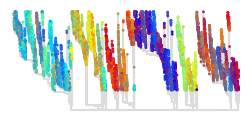

teeplots/2026-03-12-btr-foliage/layout=vertical+regime=sweep+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-12-btr-foliage/layout=vertical+regime=sweep+viz=draw-ctree+x=x+y=y+ext=.png


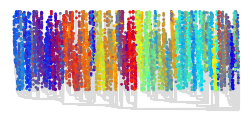

In [11]:
for regime, layout in it.product(
    ("pure", "sweep"),
    ("vertical",),
):
    df = {
        "pure": pure_canopy,
        "sweep": sweep_canopy,
    }[regime]
    with tp.teed(
        pylib.chloropleth.draw_ctree,
        df,
        x="x_",
        y="y_",
        cmap=pylib.cmap.bcyr.get_color,
        layout=layout,
        scatter_kws=dict(
            edgecolor="none",
            s=4,
        ),
        scatter_shuffle=1,
        tree_kws=dict(
            edge=dict(
                color="gainsboro",
                linewidth=0.5,
            ),
            margins=-0.05,
        ),
        teeplot_dpi=600,
        teeplot_outattrs={"regime": regime},
        teeplot_subdir=teeplot_subdir,
    ) as teed:
        teed.invert_xaxis()
        teed.invert_yaxis()
        teed.figure.set_size_inches(3, 1.33)


## Plot Fossil Scatterplot


teeplots/2026-03-12-btr-foliage/cmap=bcyr+regime=pure+viz=draw-cscatter+x=x+y=y+ext=.pdf
teeplots/2026-03-12-btr-foliage/cmap=bcyr+regime=pure+viz=draw-cscatter+x=x+y=y+ext=.png


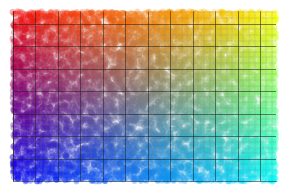

teeplots/2026-03-12-btr-foliage/cmap=bcyr+regime=sweep+viz=draw-cscatter+x=x+y=y+ext=.pdf
teeplots/2026-03-12-btr-foliage/cmap=bcyr+regime=sweep+viz=draw-cscatter+x=x+y=y+ext=.png


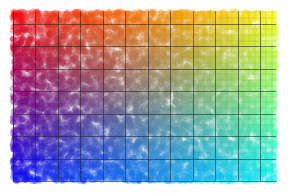

In [12]:
for regime, layout in it.product(
    ("pure", "sweep"),
    ("vertical",),
):
    df = {
        "pure": pure_canopy,
        "sweep": sweep_canopy,
    }[regime]
    with tp.teed(
        pylib.chloropleth.draw_cscatter,
        df.dropna(subset=["x_", "y_"]),
        x="x",
        y="y",
        cmap=pylib.cmap.bcyr.get_color,
        despine=True,
        major=100,
        minor=25,
        xmax=1170,
        ymax=755,
        scatter_kws=dict(
            s=20,
        ),
        teeplot_dpi=600,
        teeplot_outattrs={"cmap": "bcyr", "regime": regime},
        teeplot_subdir=teeplot_subdir,
    ) as teed:
        teed.set_aspect("equal")
        fig = teed.figure
        fig.set_size_inches(3, 2)
        fig.tight_layout()


## Combined Plots


teeplots/2026-03-12-btr-foliage/viz=subplots+ext=.pdf
teeplots/2026-03-12-btr-foliage/viz=subplots+ext=.png


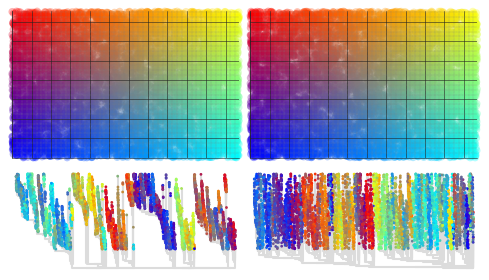

In [13]:
with tp.teed(
    plt.subplots,
    ncols=2,
    nrows=2,
    figsize=(6, 4),
    gridspec_kw={"height_ratios": [2, 1], "hspace": 0.1, "wspace": 0.05},
    teeplot_subdir=teeplot_subdir,
) as fig:
    fig, axs = fig

    for col, regime in enumerate(("pure", "sweep")):
        df = {
            "pure": pure_canopy,
            "sweep": sweep_canopy,
        }[regime]

        pylib.chloropleth.draw_cscatter(
            df.dropna(subset=["x_", "y_"]),
            x="x",
            y="y",
            cmap=pylib.cmap.bcyr.get_color,
            despine=True,
            major=100,
            minor=25,
            scatter_kws=dict(
                s=30,
            ),
            xmax=1170,
            ymax=755,
            ax=axs[0, col],
        )
        axs[0, col].set_aspect("equal", anchor="S")

        pylib.chloropleth.draw_ctree(
            df,
            x="x_",
            y="y_",
            cmap=pylib.cmap.bcyr.get_color,
            layout="vertical",
            scatter_kws=dict(
                edgecolor="none",
                s=4,
            ),
            scatter_shuffle=1,
            tree_kws=dict(
                edge=dict(
                    color="gainsboro",
                    linewidth=0.5,
                ),
                margins=-0.05,
            ),
            ax=axs[1, col],
        )
        axs[1, col].invert_xaxis()
        axs[1, col].invert_yaxis()
        axs[1, col].set_anchor("N")


In [14]:
import pymupdf

spatial_positions_path = "assets/2026-03-04-wse-spatial-phylo-positions.pdf"
spatial_template_path = "assets/2026-03-04-wse-spatial-phylo-template.pdf"

spatial_positions_doc = pymupdf.open(spatial_positions_path)
print(
    f"Positions: {len(spatial_positions_doc)} page(s), size {spatial_positions_doc[0].rect}"
)

spatial_template_doc = pymupdf.open(spatial_template_path)
print(
    f"Template:  {len(spatial_template_doc)} page(s), size {spatial_template_doc[0].rect}"
)


Positions: 1 page(s), size Rect(0.0, 0.0, 647.4000244140625, 279.6712341308594)
Template:  1 page(s), size Rect(0.0, 0.0, 647.4000244140625, 279.6712341308594)


In [15]:
spatial_target_colors = {
    "accede": "#ACCEDE",
    "beefed": "#BEEFED",
    "decade": "#DECADE",
    "deadbe": "#DEADBE",
}


def hex_to_rgb_float(hex_color):
    h = hex_color.lstrip("#")
    return tuple(int(h[i : i + 2], 16) / 255.0 for i in (0, 2, 4))


def find_rects_by_color(page, hex_color, tol=2 / 255):
    target = hex_to_rgb_float(hex_color)
    rects = []
    for path in page.get_drawings():
        fill = path.get("fill")
        if fill is None or len(fill) != 3:
            continue
        if all(abs(fill[i] - target[i]) < tol for i in range(3)):
            rects.append(path["rect"])
    return rects


spatial_positions_page = spatial_positions_doc[0]
spatial_color_rects = {}
for name, hex_color in spatial_target_colors.items():
    rects = find_rects_by_color(spatial_positions_page, hex_color)
    spatial_color_rects[name] = rects
    for r in rects:
        print(f"  {name} ({hex_color}): {r}")

spatial_positions_doc.close()


  accede (#ACCEDE): Rect(159.718994140625, 23.573999404907227, 380.58599853515625, 169.0120086669922)
  beefed (#BEEFED): Rect(395.38299560546875, 23.645000457763672, 616.25, 169.08599853515625)
  decade (#DECADE): Rect(159.9219970703125, 168.78900146484375, 380.7850036621094, 279.6719970703125)
  deadbe (#DEADBE): Rect(395.8789978027344, 168.78900146484375, 616.7459716796875, 279.6719970703125)


In [16]:
spatial_plot_paths = {
    "accede": "cmap=bcyr+regime=pure+viz=draw-cscatter+x=x+y=y+ext=.pdf",
    "beefed": "cmap=bcyr+regime=sweep+viz=draw-cscatter+x=x+y=y+ext=.pdf",
    "decade": "layout=vertical+regime=pure+viz=draw-ctree+x=x+y=y+ext=.pdf",
    "deadbe": "layout=vertical+regime=sweep+viz=draw-ctree+x=x+y=y+ext=.pdf",
}

spatial_plot_docs = {}
for name, filename in spatial_plot_paths.items():
    path = os.path.join("teeplots", teeplot_subdir, filename)
    print(f"Loading {name} from: {path}")
    spatial_plot_docs[name] = pymupdf.open(path)

page = spatial_template_doc[0]
for name, rects in spatial_color_rects.items():
    src_doc = spatial_plot_docs[name]
    for rect in rects:
        page.show_pdf_page(rect, src_doc, 0)
        print(f"  Inserted {name} at {rect}")

# set Interpolate on all raster images so PDF viewers use smooth scaling
for img in page.get_images(full=True):
    xref = img[0]
    if "/Interpolate" not in spatial_template_doc.xref_object(xref):
        spatial_template_doc.xref_set_key(xref, "Interpolate", "true")

spatial_output_destination = f"teeplots/{teeplot_subdir}/"
os.makedirs(spatial_output_destination, exist_ok=True)
spatial_output_path = os.path.join(
    spatial_output_destination,
    "wse-spatial-phylo-filled.pdf",
)
spatial_template_doc.save(spatial_output_path, garbage=4, deflate=True)
spatial_template_doc.close()
for d in spatial_plot_docs.values():
    d.close()
print(f"\nSaved to {spatial_output_path}")


Loading accede from: teeplots/2026-03-12-btr-foliage/cmap=bcyr+regime=pure+viz=draw-cscatter+x=x+y=y+ext=.pdf
Loading beefed from: teeplots/2026-03-12-btr-foliage/cmap=bcyr+regime=sweep+viz=draw-cscatter+x=x+y=y+ext=.pdf
Loading decade from: teeplots/2026-03-12-btr-foliage/layout=vertical+regime=pure+viz=draw-ctree+x=x+y=y+ext=.pdf
Loading deadbe from: teeplots/2026-03-12-btr-foliage/layout=vertical+regime=sweep+viz=draw-ctree+x=x+y=y+ext=.pdf
  Inserted accede at Rect(159.718994140625, 23.573999404907227, 380.58599853515625, 169.0120086669922)
  Inserted beefed at Rect(395.38299560546875, 23.645000457763672, 616.25, 169.08599853515625)
  Inserted decade at Rect(159.9219970703125, 168.78900146484375, 380.7850036621094, 279.6719970703125)
  Inserted deadbe at Rect(395.8789978027344, 168.78900146484375, 616.7459716796875, 279.6719970703125)

Saved to teeplots/2026-03-12-btr-foliage/wse-spatial-phylo-filled.pdf


In [17]:
spatial_filled_doc = pymupdf.open(spatial_output_path)
dpi = 600
mat = pymupdf.Matrix(dpi / 72, dpi / 72)
pix = spatial_filled_doc[0].get_pixmap(matrix=mat, alpha=False)
spatial_png_path = spatial_output_path.replace(".pdf", ".png")
pix.save(spatial_png_path)
spatial_filled_doc.close()
print(f"Saved {pix.width}x{pix.height} @ {dpi} DPI to {spatial_png_path}")


Saved 5395x2331 @ 600 DPI to teeplots/2026-03-12-btr-foliage/wse-spatial-phylo-filled.png
